In [22]:
import sys
from matplotlib import pyplot as plt
from sklift.metrics import uplift_at_k
import seaborn as sns
import numpy as np
import pandas as pd
import joblib
from sklift.models import ClassTransformation
from sklearn.calibration import CalibratedClassifierCV

from catboost import CatBoostClassifier
from sklift.metrics import qini_auc_score

# install uplift library scikit-uplift and other libraries
#!{sys.executable} -m pip install scikit-uplift dill catboost

# %config InlineBackend.figure_format = 'svg'
# %matplotlib inline

## Input dataset

In [23]:
# dataset = joblib.load("data/hillstrom.joblib")

In [24]:
# dataset.keys()

In [25]:
# # 1. Start by merging everything into one Master DataFrame
# # Assuming dataset.data is a pandas DataFrame or similar-structured object
# df_input = pd.DataFrame(dataset.data)

# # 2. Add your columns
# df_input['treatment'] = dataset.treatment # Note: or whatever your source for the treatment col is
# df_input[dataset.target.columns] = dataset.target

In [26]:
#df_input.to_parquet('data/hillstrom.parquet', index=False)

In [27]:
df_input=pd.read_parquet('data/hillstrom.parquet')
target_cols = ['treatment', 'visit', 'conversion','spend']

In [28]:
df_input.head(20)

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0
5,6,2) $100 - $200,134.83,0,1,Surburban,0,Phone,Womens E-Mail,1,0,0.0
6,9,3) $200 - $350,280.20,1,0,Surburban,1,Phone,Womens E-Mail,0,0,0.0
7,9,1) $0 - $100,46.42,0,1,Urban,0,Phone,Womens E-Mail,0,0,0.0
8,9,5) $500 - $750,675.07,1,1,Rural,1,Phone,Mens E-Mail,0,0,0.0
9,10,1) $0 - $100,32.84,0,1,Urban,1,Web,Womens E-Mail,0,0,0.0


### Feature leakage check

In [29]:
pd.DataFrame(df_input[['mens','womens','treatment','visit']].value_counts(dropna=False)).reset_index()

,mens,womens,treatment,visit,count
0,1,0,No E-Mail,0,8676
1,0,1,No E-Mail,0,8607
2,1,0,Womens E-Mail,0,8555
3,0,1,Womens E-Mail,0,8009
4,0,1,Mens E-Mail,0,7976
5,1,0,Mens E-Mail,0,7943
6,1,1,No E-Mail,0,1761
7,0,1,Womens E-Mail,1,1638
8,1,0,Mens E-Mail,1,1615
9,0,1,Mens E-Mail,1,1592


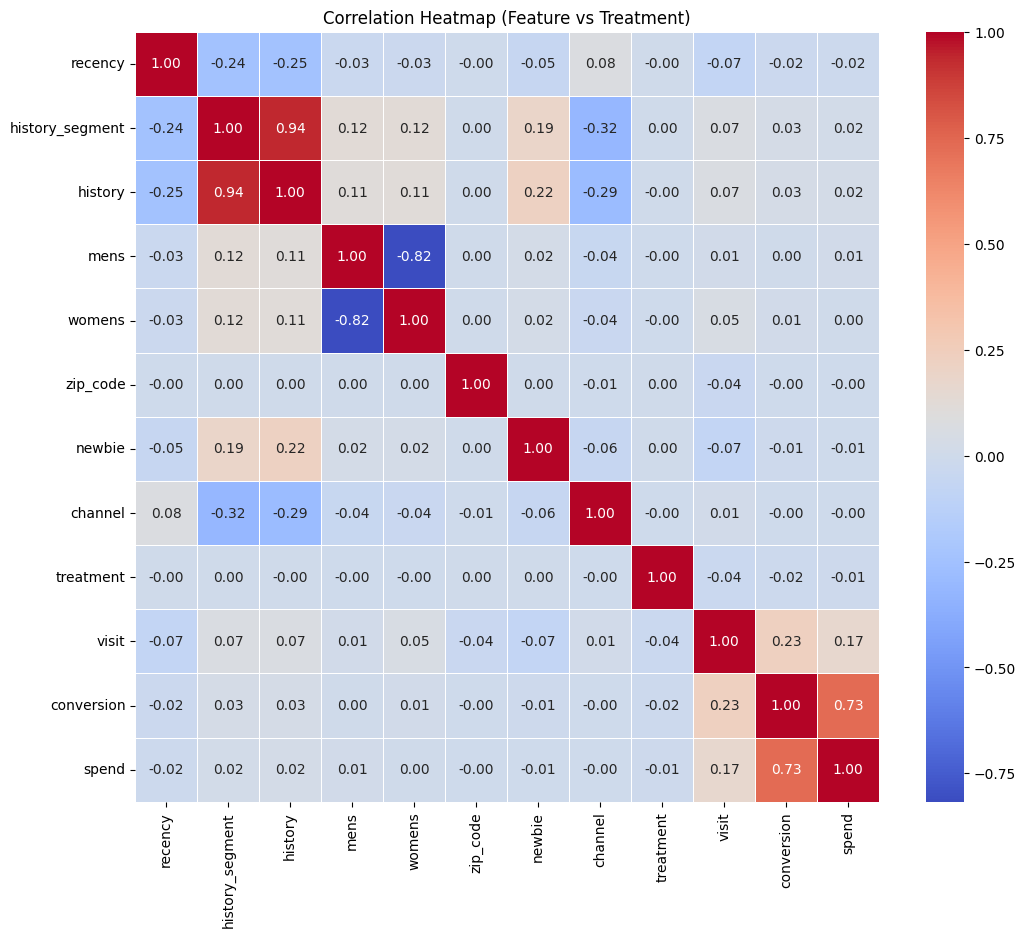

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a copy for the heatmap
# We convert everything to numeric so we can calculate correlations
corr_df = df_input.copy()

# 2. Encode categorical columns to numeric
# 'treatment' must be encoded: Womens E-Mail=2, Mens E-Mail=1, No E-Mail=0
#corr_df['treatment'] = corr_df['treatment'].map({'Womens E-Mail': 2, 'Mens E-Mail': 1, 'No E-Mail': 0})

# Encode others: Zip_Code, Channel, History_Segment
cat_cols = ['zip_code', 'channel', 'history_segment','treatment']
for col in cat_cols:
    corr_df[col] = corr_df[col].astype('category').cat.codes

# 3. Calculate Correlation Matrix
corr_matrix = corr_df.corr()

# 4. Plot Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Feature vs Treatment)")
plt.show()

In [31]:
df_input.columns

Index(['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code',
       'newbie', 'channel', 'treatment', 'visit', 'conversion', 'spend'],
      dtype='object')

## Men Modelling 
Filter out Women E-mail treatment

In [32]:
df_men=df_input[df_input['treatment']!='Womens E-Mail']

In [33]:
df_men.shape

(42613, 12)

In [34]:
df_men['treatment'].value_counts()

treatment
Mens E-Mail    21307
No E-Mail      21306
Name: count, dtype: int64

In [35]:
treatment_map = {'No E-Mail': 0, 'Mens E-Mail': 1}
df_men['treatment'] = df_men['treatment'].map(treatment_map)

C:\Users\vncpyy7h\AppData\Local\Temp\ipykernel_11704\4169295510.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_men['treatment'] = df_men['treatment'].map(treatment_map)


In [36]:
df_men['treatment'].value_counts()

treatment
1    21307
0    21306
Name: count, dtype: int64

In [37]:
df_men

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,visit,conversion,spend
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,0,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,1,0,0,0.0
8,9,5) $500 - $750,675.07,1,1,Rural,1,Phone,1,0,0,0.0
13,2,2) $100 - $200,101.64,0,1,Urban,0,Web,1,1,0,0.0
14,4,3) $200 - $350,241.42,0,1,Rural,1,Multichannel,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
63994,7,1) $0 - $100,86.46,0,1,Urban,0,Web,1,0,0,0.0
63995,10,2) $100 - $200,105.54,1,0,Urban,0,Web,1,0,0,0.0
63996,5,1) $0 - $100,38.91,0,1,Urban,1,Phone,1,0,0,0.0
63997,6,1) $0 - $100,29.99,1,0,Urban,1,Phone,1,0,0,0.0


In [38]:
pd.pivot_table(df_men, index='treatment',columns='conversion', values='recency', aggfunc=['mean','count' ])

mean            count     
conversion         0         1      0    1
treatment                                 
0           5.757836  4.336066  21184  122
1           5.782890  5.044944  21040  267

In [39]:
from sklearn.model_selection import train_test_split

stratify_cols = pd.concat([df_men['treatment'], df_men['conversion']], axis=1)

X_train, X_val, trmnt_train, trmnt_val, y_train, y_val = train_test_split(
    df_men.drop(columns=target_cols),
    df_men['treatment'],
    df_men['conversion'],
    stratify=stratify_cols,
    test_size=0.3,
    random_state=41
)

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")

Train shape: (29829, 8)
Validation shape: (12784, 8)


In [40]:
z_val = np.where((trmnt_val == 1) & (y_val == 1), 1,
          np.where((trmnt_val == 0) & (y_val == 0), 1, 0))

In [41]:
estimator = CatBoostClassifier(
    iterations=1000,          # Allow up to 1000, but early stopping will cut it short
    learning_rate=0.03,       # Slower is safer (standard for CatBoost)
    depth=4,                  # VERY IMPORTANT: Keep between 3 and 5. Deep trees memorize noise.
    l2_leaf_reg=10,           # Higher values (e.g., 10-20) force the model to be simpler
    min_data_in_leaf=50,      # Force each tree leaf to represent at least 50 users
    random_strength=1,        # Prevents tree from overfitting to specific training samples
    
    # Early Stopping
    early_stopping_rounds=50,
    
    # Categorical handling
    cat_features=['womens', 'mens', 'channel', 'zip_code', 'history_segment', 'newbie'],
    
    # Misc
    random_state=42,
    thread_count=1,
    verbose=50                # Print less often to keep your console clean
)

ct_model = ClassTransformation(estimator=estimator)

In [42]:
ct_model.fit(
    X=X_train, y=y_train, treatment=trmnt_train,
    estimator_fit_params={'eval_set': (X_val, z_val),'early_stopping_rounds': 50} # Now the model has eyes!
)

0:	learn: 0.6931355	test: 0.6931492	best: 0.6931492 (0)	total: 40ms	remaining: 39.9s
50:	learn: 0.6926716	test: 0.6931826	best: 0.6931492 (0)	total: 2.07s	remaining: 38.5s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6931492263
bestIteration = 0

Shrink model to first 1 iterations.


,estimator,"CatBoostClass...1, verbose=50)"


In [43]:
from sklearn.model_selection import KFold
import numpy as np
import pandas as pd
from sklift.metrics import uplift_at_k
from catboost import CatBoostClassifier
from sklift.models import ClassTransformation

# 1. Define X, y, t
X = df_men.drop(columns=target_cols)
y = df_men['conversion']
t = df_men['treatment']

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store results
results = []
trained_models = []


for fold, (train_index, val_index) in enumerate(kf.split(X, y)):
    # Slice the data
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]
    t_train_fold, t_val_fold = t.iloc[train_index], t.iloc[val_index]
    
    # Generate the Z-label
    z_train_fold = np.where((t_train_fold == 1) & (y_train_fold == 1), 1,
                     np.where((t_train_fold == 0) & (y_train_fold == 0), 1, 0))
    z_val_fold = np.where((t_val_fold == 1) & (y_val_fold == 1), 1,
                   np.where((t_val_fold == 0) & (y_val_fold == 0), 1, 0))
    
    # Initialize and Fit
    estimator = CatBoostClassifier(
        iterations=1000, depth=4, learning_rate=0.05,
        cat_features=['womens', 'mens', 'channel', 'zip_code', 'history_segment', 'newbie'],
        early_stopping_rounds=50, random_state=42, thread_count=1, verbose=0
    )
    
    ct_model = ClassTransformation(estimator=estimator)
    
    ct_model.fit(
        X_train_fold, y_train_fold, treatment=t_train_fold,
        estimator_fit_params={
            'eval_set': (X_val_fold, z_val_fold),
            'early_stopping_rounds': 50
        }
    )
    
    # Predict
    train_preds = ct_model.predict(X_train_fold)
    val_preds = ct_model.predict(X_val_fold)
    
    # Score
    train_score = uplift_at_k(y_train_fold, train_preds, t_train_fold, strategy='overall', k=0.1)
    val_score = uplift_at_k(y_val_fold, val_preds, t_val_fold, strategy='overall', k=0.1)
    
    results.append({
        "Fold": fold + 1,
        "Train Uplift": train_score,
        "Validation Uplift": val_score
    })

    trained_models.append(ct_model)


# Convert to DataFrame
results_df = pd.DataFrame(results)

# Add average row
avg_row = pd.DataFrame({
    "Fold": ["Average"],
    "Train Uplift": [results_df["Train Uplift"].mean()],
    "Validation Uplift": [results_df["Validation Uplift"].mean()]
})

results_df = pd.concat([results_df, avg_row], ignore_index=True)
print(results_df)

      Fold  Train Uplift  Validation Uplift
0        1      0.007749           0.004902
1        2      0.009621           0.011055
2        3      0.006333           0.011494
3        4      0.012263           0.004256
4        5      0.008464           0.008603
5  Average      0.008886           0.008062


In [44]:
ct_model=trained_models[2]

In [45]:
## Save model
joblib.dump(ct_model, 'models/mens_uplift_model_conversion.pkl')

['models/mens_uplift_model_conversion.pkl']

In [46]:
# 1. Get predictions for both sets
# Remember: ct_model_mens is the one you already trained on X_train
train_preds = ct_model.predict(X_train)
val_preds = ct_model.predict(X_val)

# 2. Calculate Qini scores
qini_train = qini_auc_score(
    y_true=y_train, 
    uplift=train_preds, 
    treatment=trmnt_train
)

qini_val = qini_auc_score(
    y_true=y_val, 
    uplift=val_preds, 
    treatment=trmnt_val
)

print(f"Qini Score (Train): {qini_train:.4f}")
print(f"Qini Score (Validation): {qini_val:.4f}")

Qini Score (Train): -0.0396
Qini Score (Validation): 0.1441


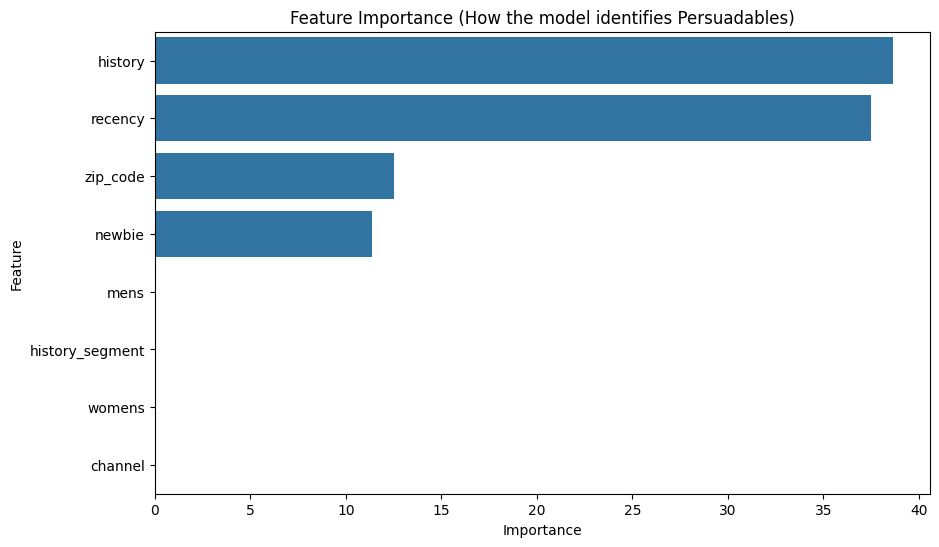

           Feature  Importance
2          history   38.637783
0          recency   37.494634
5         zip_code   12.502882
6           newbie   11.364701
3             mens    0.000000
1  history_segment    0.000000
4           womens    0.000000
7          channel    0.000000


In [47]:
# 1. Get the underlying estimator
# This is the trained CatBoost model
fitted_estimator = ct_model.estimator

# 2. Get the feature importances
# CatBoost provides 'feature_importances_'
importances = fitted_estimator.feature_importances_

# 3. Create a clean DataFrame for viewing
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Plot it
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Feature Importance (How the model identifies Persuadables)")
plt.show()

print(importance_df)

In [48]:
from sklift.metrics import uplift_at_k
import pandas as pd

k = 0.1

# 1. Calculate for TOP 10% (Using original predictions)
top_train_overall = uplift_at_k(y_train, train_preds, trmnt_train, strategy='overall', k=k)
top_val_overall = uplift_at_k(y_val, val_preds, trmnt_val, strategy='overall', k=k)

# 2. Calculate for BOTTOM 10% (By flipping the sign of the predictions)
# By multiplying by -1, the "lowest" scores become the "highest"
bot_train_overall = uplift_at_k(y_train, -train_preds, trmnt_train, strategy='overall', k=k)
bot_val_overall = uplift_at_k(y_val, -val_preds, trmnt_val, strategy='overall', k=k)

# 3. Create the comparison table
results_df = pd.DataFrame({
    "Segment": ["Top 10% (Original)", "Bottom 10% (Flipped)"],
    "Train Uplift": [top_train_overall, bot_train_overall],
    "Validation Uplift": [top_val_overall, bot_val_overall]
})

print(results_df)

                Segment  Train Uplift  Validation Uplift
0    Top 10% (Original)      0.008389           0.011476
1  Bottom 10% (Flipped)      0.006495          -0.001462


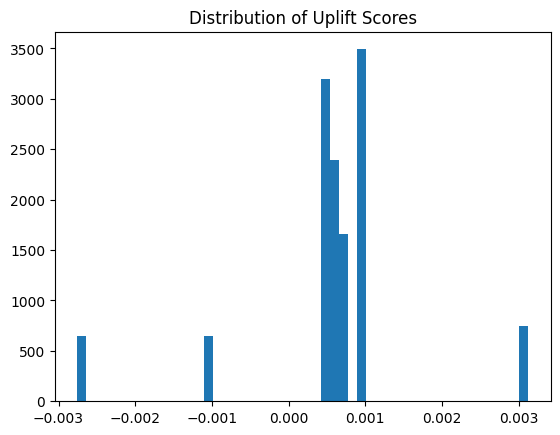

In [49]:
import matplotlib.pyplot as plt
plt.hist(val_preds, bins=50)
plt.title("Distribution of Uplift Scores")
plt.show()

## Women Modelling 
Filter out Men E-mail treatment

In [86]:
df_women=df_input[df_input['treatment']!='Mens E-Mail']

In [87]:
df_women.shape

(42693, 12)

In [88]:
df_women[['treatment','conversion']].value_counts()

treatment      conversion
Womens E-Mail  0             21198
No E-Mail      0             21184
Womens E-Mail  1               189
No E-Mail      1               122
Name: count, dtype: int64

In [89]:
treatment_map = {'No E-Mail': 0, 'Womens E-Mail': 1}
df_women['treatment'] = df_women['treatment'].map(treatment_map)


C:\Users\vncpyy7h\AppData\Local\Temp\ipykernel_11704\2065503433.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_women['treatment'] = df_women['treatment'].map(treatment_map)


In [90]:
df_women['treatment'].value_counts()

treatment
1    21387
0    21306
Name: count, dtype: int64

In [91]:
df_women

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,1,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,0,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,1,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,1,0,0,0.0
5,6,2) $100 - $200,134.83,0,1,Surburban,0,Phone,1,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
63989,10,3) $200 - $350,304.30,1,1,Surburban,0,Web,1,1,0,0.0
63990,6,1) $0 - $100,80.02,0,1,Surburban,0,Phone,0,0,0,0.0
63991,1,3) $200 - $350,306.10,1,0,Surburban,1,Phone,1,0,0,0.0
63993,4,4) $350 - $500,374.07,0,1,Surburban,0,Phone,1,0,0,0.0


In [92]:
pd.pivot_table(df_women, index='treatment',columns='conversion', values='recency', aggfunc=['mean','count' ])

mean            count     
conversion         0         1      0    1
treatment                                 
0           5.757836  4.336066  21184  122
1           5.775073  4.957672  21198  189

In [93]:
from sklearn.model_selection import train_test_split

stratify_cols = pd.concat([df_women['treatment'], df_women['conversion']], axis=1)

X_train, X_val, trmnt_train, trmnt_val, y_train, y_val = train_test_split(
    df_women.drop(columns=target_cols),
    df_women['treatment'],
    df_women['conversion'],
    stratify=stratify_cols,
    test_size=0.3,
    random_state=41
)

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")

Train shape: (29885, 8)
Validation shape: (12808, 8)


In [94]:
X_train.columns

Index(['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code',
       'newbie', 'channel'],
      dtype='object')

In [58]:
z_val = np.where((trmnt_val == 1) & (y_val == 1), 1,
          np.where((trmnt_val == 0) & (y_val == 0), 1, 0))

In [75]:
z_train = np.where((trmnt_train == 1) & (y_train == 1), 1,
          np.where((trmnt_train == 0) & (y_train == 0), 1, 0))

In [84]:
df_women[['treatment','conversion']].value_counts(dropna=False)

treatment  conversion
1          0             21198
0          0             21184
1          1               189
0          1               122
Name: count, dtype: int64

In [82]:
pd.DataFrame(z_train).value_counts(dropna=False)

0
1    14961
0    14924
Name: count, dtype: int64

In [95]:
df_women

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,1,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,0,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,1,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,1,0,0,0.0
5,6,2) $100 - $200,134.83,0,1,Surburban,0,Phone,1,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
63989,10,3) $200 - $350,304.30,1,1,Surburban,0,Web,1,1,0,0.0
63990,6,1) $0 - $100,80.02,0,1,Surburban,0,Phone,0,0,0,0.0
63991,1,3) $200 - $350,306.10,1,0,Surburban,1,Phone,1,0,0,0.0
63993,4,4) $350 - $500,374.07,0,1,Surburban,0,Phone,1,0,0,0.0


In [96]:
estimator = CatBoostClassifier(
    iterations=1000,          # Allow up to 1000, but early stopping will cut it short
    learning_rate=0.03,       # Slower is safer (standard for CatBoost)
    depth=4,                  # VERY IMPORTANT: Keep between 3 and 5. Deep trees memorize noise.
    l2_leaf_reg=10,           # Higher values (e.g., 10-20) force the model to be simpler
    min_data_in_leaf=50,      # Force each tree leaf to represent at least 50 users
    random_strength=1,        # Prevents tree from overfitting to specific training samples
    
    # Early Stopping
    early_stopping_rounds=50,
    
    # Categorical handling
    cat_features=['womens', 'mens', 'channel', 'zip_code', 'history_segment', 'newbie'],
    
    # Misc
    random_state=42,
    thread_count=1,
    verbose=50                # Print less often to keep your console clean
)

ct_model = ClassTransformation(estimator=estimator)

In [97]:
ct_model.fit(
    X=X_train, y=y_train, treatment=trmnt_train,
    estimator_fit_params={'eval_set': (X_val, z_val),'early_stopping_rounds': 50} # Now the model has eyes!
)

0:	learn: 0.6931335	test: 0.6931535	best: 0.6931535 (0)	total: 55.3ms	remaining: 55.3s
50:	learn: 0.6928429	test: 0.6932027	best: 0.6931535 (0)	total: 2.05s	remaining: 38.1s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6931535289
bestIteration = 0

Shrink model to first 1 iterations.


,estimator,"CatBoostClass...1, verbose=50)"


In [98]:
ct_model.estimator.feature_importances_

array([48.00256652,  0.        , 35.15179149,  0.        ,  0.        ,
        0.6929427 ,  0.        , 16.15269929])

In [106]:
df_women

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,1,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,0,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,1,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,1,0,0,0.0
5,6,2) $100 - $200,134.83,0,1,Surburban,0,Phone,1,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
63989,10,3) $200 - $350,304.30,1,1,Surburban,0,Web,1,1,0,0.0
63990,6,1) $0 - $100,80.02,0,1,Surburban,0,Phone,0,0,0,0.0
63991,1,3) $200 - $350,306.10,1,0,Surburban,1,Phone,1,0,0,0.0
63993,4,4) $350 - $500,374.07,0,1,Surburban,0,Phone,1,0,0,0.0


In [107]:
X

,recency,history_segment,history,mens,womens,zip_code,newbie,channel
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web
5,6,2) $100 - $200,134.83,0,1,Surburban,0,Phone
...,...,...,...,...,...,...,...,...
63989,10,3) $200 - $350,304.30,1,1,Surburban,0,Web
63990,6,1) $0 - $100,80.02,0,1,Surburban,0,Phone
63991,1,3) $200 - $350,306.10,1,0,Surburban,1,Phone
63993,4,4) $350 - $500,374.07,0,1,Surburban,0,Phone


In [112]:
df_women=df_women.reset_index(drop=True)

In [113]:
df_women

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,1,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,0,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,1,0,0,0.0
3,2,1) $0 - $100,45.34,1,0,Urban,0,Web,1,0,0,0.0
4,6,2) $100 - $200,134.83,0,1,Surburban,0,Phone,1,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
42688,10,3) $200 - $350,304.30,1,1,Surburban,0,Web,1,1,0,0.0
42689,6,1) $0 - $100,80.02,0,1,Surburban,0,Phone,0,0,0,0.0
42690,1,3) $200 - $350,306.10,1,0,Surburban,1,Phone,1,0,0,0.0
42691,4,4) $350 - $500,374.07,0,1,Surburban,0,Phone,1,0,0,0.0


In [114]:
from sklearn.model_selection import KFold
import numpy as np
import pandas as pd
from sklift.metrics import uplift_at_k
from catboost import CatBoostClassifier
from sklift.models import ClassTransformation

# 1. Define X, y, t
X = df_women.drop(columns=target_cols)
y = df_women['conversion']
t = df_women['treatment']

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store results
results = []
trained_models = []


for fold, (train_index, val_index) in enumerate(kf.split(X, y)):
    # Slice the data
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]
    t_train_fold, t_val_fold = t.iloc[train_index], t.iloc[val_index]
    
    # Generate the Z-label
    z_train_fold = np.where((t_train_fold == 1) & (y_train_fold == 1), 1,
                     np.where((t_train_fold == 0) & (y_train_fold == 0), 1, 0))
    z_val_fold = np.where((t_val_fold == 1) & (y_val_fold == 1), 1,
                   np.where((t_val_fold == 0) & (y_val_fold == 0), 1, 0))
    
    # Initialize and Fit
    estimator = CatBoostClassifier(
        iterations=1000, depth=4, learning_rate=0.03,
        cat_features=['womens', 'mens', 'channel', 'zip_code', 'history_segment', 'newbie'],
        early_stopping_rounds=50, random_state=42, thread_count=1, verbose=0
    )
    
    ct_model = ClassTransformation(estimator=estimator)
    
    ct_model.fit(
        X_train_fold, y_train_fold, treatment=t_train_fold,
        estimator_fit_params={
            'eval_set': (X_val_fold, z_val_fold),
            'early_stopping_rounds': 50
        }
    )
    
    # Predict
    train_preds = ct_model.predict(X_train_fold)
    val_preds = ct_model.predict(X_val_fold)
    
    # Score
    train_score = uplift_at_k(y_train_fold, train_preds, t_train_fold, strategy='overall', k=0.1)
    val_score = uplift_at_k(y_val_fold, val_preds, t_val_fold, strategy='overall', k=0.1)
    
    results.append({
        "Fold": fold + 1,
        "Train Uplift": train_score,
        "Validation Uplift": val_score
    })

    trained_models.append(ct_model)


# Convert to DataFrame
results_df = pd.DataFrame(results)

# Add average row
avg_row = pd.DataFrame({
    "Fold": ["Average"],
    "Train Uplift": [results_df["Train Uplift"].mean()],
    "Validation Uplift": [results_df["Validation Uplift"].mean()]
})

results_df = pd.concat([results_df, avg_row], ignore_index=True)
print(results_df)

      Fold  Train Uplift  Validation Uplift
0        1      0.000408           0.004640
1        2      0.003710          -0.008821
2        3      0.002709           0.002621
3        4      0.003824          -0.006862
4        5      0.001949           0.009662
5  Average      0.002520           0.000248


In [126]:
ct_model=trained_models[3]

In [127]:
ct_model.estimator.feature_importances_

array([14.16807813, 10.53748653, 12.84150475,  3.79289398,  0.        ,
       31.62785423,  0.        , 27.03218239])

In [128]:
## Save model
joblib.dump(ct_model, 'models/womens_uplift_model_conversion.pkl')

['models/womens_uplift_model_conversion.pkl']

In [129]:
# 1. Get predictions for both sets
# Remember: ct_model_mens is the one you already trained on X_train
train_preds = ct_model.predict(X_train)
val_preds = ct_model.predict(X_val)

# 2. Calculate Qini scores
qini_train = qini_auc_score(
    y_true=y_train, 
    uplift=train_preds, 
    treatment=trmnt_train
)

qini_val = qini_auc_score(
    y_true=y_val, 
    uplift=val_preds, 
    treatment=trmnt_val
)

print(f"Qini Score (Train): {qini_train:.4f}")
print(f"Qini Score (Validation): {qini_val:.4f}")

Qini Score (Train): -0.0590
Qini Score (Validation): -0.1188


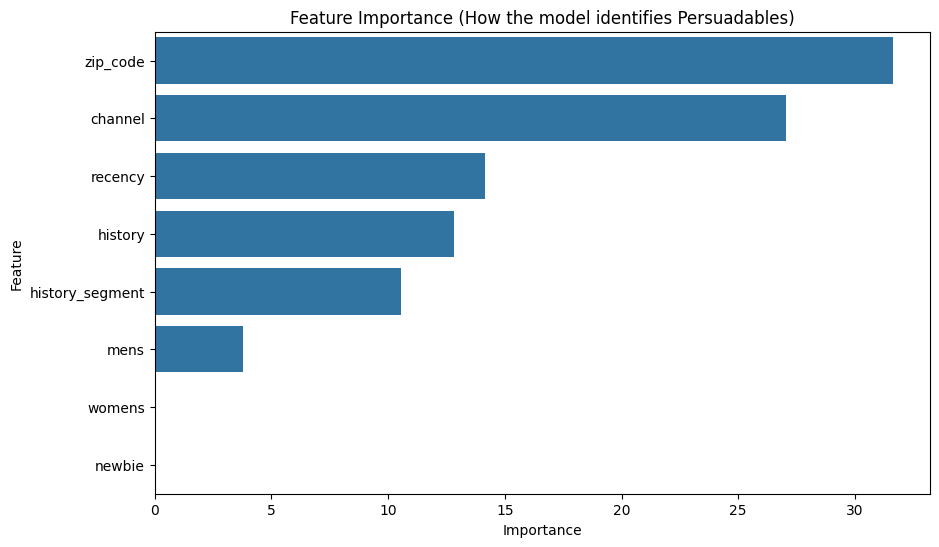

           Feature  Importance
5         zip_code   31.627854
7          channel   27.032182
0          recency   14.168078
2          history   12.841505
1  history_segment   10.537487
3             mens    3.792894
4           womens    0.000000
6           newbie    0.000000


In [130]:
# 1. Get the underlying estimator
# This is the trained CatBoost model
fitted_estimator = ct_model.estimator

# 2. Get the feature importances
# CatBoost provides 'feature_importances_'
importances = fitted_estimator.feature_importances_

# 3. Create a clean DataFrame for viewing
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Plot it
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Feature Importance (How the model identifies Persuadables)")
plt.show()

print(importance_df)

In [131]:
from sklift.metrics import uplift_at_k
import pandas as pd

k = 0.1

# 1. Calculate for TOP 10% (Using original predictions)
top_train_overall = uplift_at_k(y_train, train_preds, trmnt_train, strategy='overall', k=k)
top_val_overall = uplift_at_k(y_val, val_preds, trmnt_val, strategy='overall', k=k)

# 2. Calculate for BOTTOM 10% (By flipping the sign of the predictions)
# By multiplying by -1, the "lowest" scores become the "highest"
bot_train_overall = uplift_at_k(y_train, -train_preds, trmnt_train, strategy='overall', k=k)
bot_val_overall = uplift_at_k(y_val, -val_preds, trmnt_val, strategy='overall', k=k)

# 3. Create the comparison table
results_df = pd.DataFrame({
    "Segment": ["Top 10% (Original)", "Bottom 10% (Flipped)"],
    "Train Uplift": [top_train_overall, bot_train_overall],
    "Validation Uplift": [top_val_overall, bot_val_overall]
})

print(results_df)

                Segment  Train Uplift  Validation Uplift
0    Top 10% (Original)      0.003929           0.001670
1  Bottom 10% (Flipped)      0.006352           0.010179


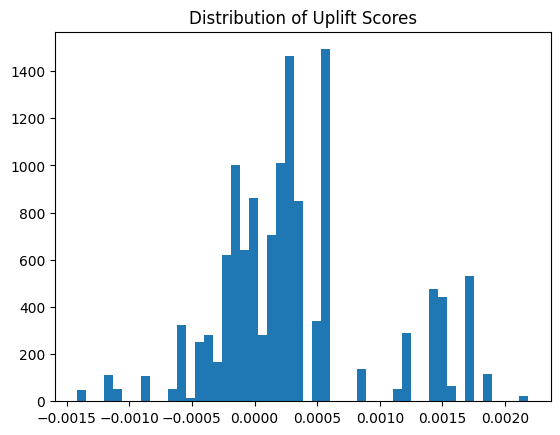

In [132]:
import matplotlib.pyplot as plt
plt.hist(val_preds, bins=50)
plt.title("Distribution of Uplift Scores")
plt.show()